In [3]:
import os
os.makedirs('/content/drive/MyDrive/4-2/Deep Learning/Assignments/Assignment-4/results/part-A/', exist_ok=True)

In [4]:
#cell 3
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

SAVE_PATH = '/content/drive/MyDrive/4-2/Deep Learning/Assignments/Assignment-4/results/part-A/'

In [5]:
def build_input():
    ch1 = np.array([
        [1,  2,  3,  4],
        [5,  6,  7,  8],
        [9,  10, 11, 12],
        [13, 14, 15, 16]
    ], dtype=np.float32)

    ch2 = np.array([
        [2, 4, 6, 8],
        [1, 3, 5, 7],
        [0, 2, 4, 6],
        [1, 3, 5, 7]
    ], dtype=np.float32)

    inp = np.stack([ch1, ch2], axis=-1)
    return inp.reshape(1, 4, 4, 2)


def build_kernel():
    k1 = np.array([[1, 0], [0, 1]], dtype=np.float32)
    k2 = np.array([[0, 1], [1, 0]], dtype=np.float32)
    kernel = np.stack([k1, k2], axis=-1)
    kernel = np.stack([kernel, kernel], axis=-1)
    return kernel

In [6]:
def conv_no_padding_stride2(inp, kernel):
    x = tf.constant(inp)
    k = tf.constant(kernel)
    out = tf.nn.conv2d(x, k, strides=[1, 2, 2, 1], padding='VALID')
    n, h, w, c = inp.shape[0], inp.shape[1], inp.shape[2], inp.shape[3]
    kh, kw = kernel.shape[0], kernel.shape[1]
    oh = (h - kh) // 2 + 1
    ow = (w - kw) // 2 + 1
    oc = kernel.shape[3]
    print(f"[Q1] Input: {inp.shape[1]}x{inp.shape[2]}x{inp.shape[3]} | Kernel: {kh}x{kw}x{kernel.shape[2]}x{oc} | Stride: 2 | Padding: VALID")
    print(f"[Q1] Output dim: ({oh}, {ow}, {oc})")
    print(f"[Q1] Output values:\n{out.numpy()[0]}")
    return out.numpy()[0], (oh, ow, oc)


def conv_with_padding_stride2(inp, kernel):
    x = tf.constant(inp)
    k = tf.constant(kernel)
    out = tf.nn.conv2d(x, k, strides=[1, 2, 2, 1], padding='SAME')
    import math
    n, h, w, c = inp.shape[0], inp.shape[1], inp.shape[2], inp.shape[3]
    kh, kw = kernel.shape[0], kernel.shape[1]
    oh = math.ceil(h / 2)
    ow = math.ceil(w / 2)
    oc = kernel.shape[3]
    print(f"\n[Q2] Input: {h}x{w}x{c} | Kernel: {kh}x{kw}x{kernel.shape[2]}x{oc} | Stride: 2 | Padding: SAME")
    print(f"[Q2] Output dim: ({oh}, {ow}, {oc})")
    print(f"[Q2] Output values:\n{out.numpy()[0]}")
    return out.numpy()[0], (oh, ow, oc)


def depthwise_conv_no_padding_stride1(inp, kernel):
    x = tf.constant(inp)
    dw_kernel = kernel[:, :, :, 0:1]
    dw_kernel = tf.tile(dw_kernel, [1, 1, 1, 1])
    dw_k = kernel[:, :, :, :1]
    dw_kernel_full = np.stack([
        kernel[:, :, 0, 0],
        kernel[:, :, 1, 1]
    ], axis=-1).reshape(2, 2, 2, 1)
    dw_k_tf = tf.constant(dw_kernel_full, dtype=tf.float32)
    out = tf.nn.depthwise_conv2d(x, dw_k_tf, strides=[1, 1, 1, 1], padding='VALID')
    n, h, w, c = inp.shape[0], inp.shape[1], inp.shape[2], inp.shape[3]
    kh, kw = 2, 2
    oh = h - kh + 1
    ow = w - kw + 1
    oc = c
    print(f"\n[Q3] Depthwise | Input: {h}x{w}x{c} | Kernel per ch: {kh}x{kw} | Stride: 1 | Padding: VALID")
    print(f"[Q3] Output dim: ({oh}, {ow}, {oc})")
    print(f"[Q3] Output values:\n{out.numpy()[0]}")
    return out.numpy()[0], (oh, ow, oc)

In [7]:
def visualize_results(inp, q1_out, q1_dim, q2_out, q2_dim, q3_out, q3_dim):
    fig = plt.figure(figsize=(18, 12))
    gs = gridspec.GridSpec(3, 5, figure=fig, hspace=0.55, wspace=0.4)

    ch1 = inp[0, :, :, 0]
    ch2 = inp[0, :, :, 1]

    cmap = 'YlOrRd'

    def add_values(ax, data):
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                ax.text(j, i, f'{data[i,j]:.0f}', ha='center', va='center', fontsize=9, fontweight='bold')

    ax = fig.add_subplot(gs[0, 0])
    ax.imshow(ch1, cmap=cmap)
    add_values(ax, ch1)
    ax.set_title('Input Ch1\n(4×4)', fontsize=9)
    ax.axis('off')

    ax = fig.add_subplot(gs[0, 1])
    ax.imshow(ch2, cmap=cmap)
    add_values(ax, ch2)
    ax.set_title('Input Ch2\n(4×4)', fontsize=9)
    ax.axis('off')

    k1 = np.array([[1,0],[0,1]], dtype=np.float32)
    k2 = np.array([[0,1],[1,0]], dtype=np.float32)

    ax = fig.add_subplot(gs[0, 2])
    ax.imshow(k1, cmap='Blues')
    add_values(ax, k1)
    ax.set_title('Kernel Ch1\n(2×2)', fontsize=9)
    ax.axis('off')

    ax = fig.add_subplot(gs[0, 3])
    ax.imshow(k2, cmap='Blues')
    add_values(ax, k2)
    ax.set_title('Kernel Ch2\n(2×2)', fontsize=9)
    ax.axis('off')

    ax = fig.add_subplot(gs[0, 4])
    ax.text(0.5, 0.5, 'Part A\nInputs & Kernels', ha='center', va='center',
            fontsize=11, fontweight='bold', transform=ax.transAxes)
    ax.axis('off')

    ax = fig.add_subplot(gs[1, 0:2])
    out1 = q1_out[:, :, 0]
    im = ax.imshow(out1, cmap=cmap)
    add_values(ax, out1)
    ax.set_title(f'Q1: No Padding | Stride=2\nOutput {q1_dim[0]}×{q1_dim[1]}×{q1_dim[2]}', fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

    for f in range(q2_out.shape[-1]):
        ax = fig.add_subplot(gs[1, 2 + f])
        d = q2_out[:, :, f]
        im = ax.imshow(d, cmap=cmap)
        add_values(ax, d)
        ax.set_title(f'Q2: Zero Pad | Stride=2\nFilter {f+1} — {q2_dim[0]}×{q2_dim[1]}', fontsize=9)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)

    for c in range(q3_out.shape[-1]):
        ax = fig.add_subplot(gs[2, c*2: c*2+2])
        d = q3_out[:, :, c]
        im = ax.imshow(d, cmap=cmap)
        add_values(ax, d)
        ax.set_title(f'Q3: Depthwise | Stride=1\nCh{c+1} Output — {q3_dim[0]}×{q3_dim[1]}', fontsize=9)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)

    fig.suptitle('Part A — Feature Map Computation (TensorFlow/Keras)', fontsize=13, fontweight='bold', y=0.98)
    plt.savefig(SAVE_PATH + 'part_a_results.png', dpi=150, bbox_inches='tight')
    plt.show()

[Q1] Input: 4x4x2 | Kernel: 2x2x2x2 | Stride: 2 | Padding: VALID
[Q1] Output dim: (2, 2, 2)
[Q1] Output values:
[[[12. 12.]
  [24. 24.]]

 [[26. 26.]
  [38. 38.]]]

[Q2] Input: 4x4x2 | Kernel: 2x2x2x2 | Stride: 2 | Padding: SAME
[Q2] Output dim: (2, 2, 2)
[Q2] Output values:
[[[12. 12.]
  [24. 24.]]

 [[26. 26.]
  [38. 38.]]]

[Q3] Depthwise | Input: 4x4x2 | Kernel per ch: 2x2 | Stride: 1 | Padding: VALID
[Q3] Output dim: (3, 3, 2)
[Q3] Output values:
[[[ 7.  5.]
  [ 9.  9.]
  [11. 13.]]

 [[15.  3.]
  [17.  7.]
  [19. 11.]]

 [[23.  3.]
  [25.  7.]
  [27. 11.]]]


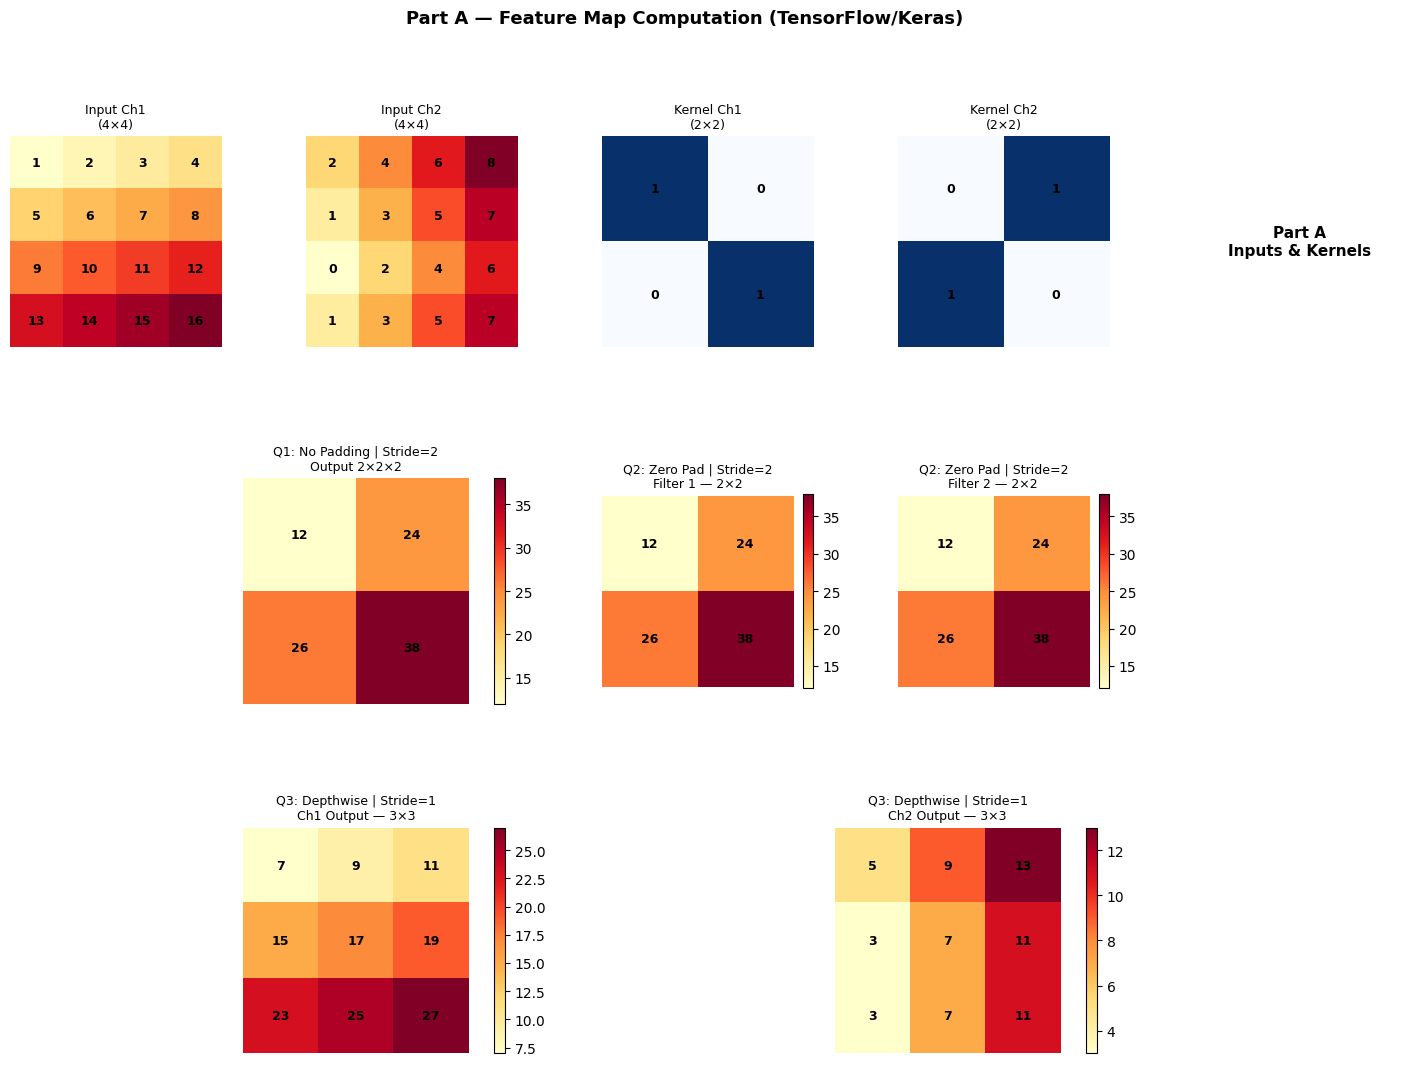

In [8]:
def main():
    inp = build_input()
    kernel = build_kernel()

    q1_out, q1_dim = conv_no_padding_stride2(inp, kernel)
    q2_out, q2_dim = conv_with_padding_stride2(inp, kernel)
    q3_out, q3_dim = depthwise_conv_no_padding_stride1(inp, kernel)

    visualize_results(inp, q1_out, q1_dim, q2_out, q2_dim, q3_out, q3_dim)


main()